![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

# Objectives
Perform an appropriate hypothesis test to determine the p-value, and hence result, of whether to reject or fail to reject the null hypothesis that the _mean number of goals scored in women's international soccer matches is the same as men's_. Use a **10% significance level.**

For this analysis, you'll use Official `FIFA World Cup` matches since `2002-01-01`, and you'll also assume that each match is fully independent, i.e., team form is ignored.

The p-value and the result of the test must be stored in a dictionary called `result_dict` in the form:
> `result_dict = {"p_val": p_val, "result": result}`

where `p_val` is the p-value and `result` is either the string `"fail to reject"` or `"reject"`, depending on the result of the test.

In [75]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, mannwhitneyu

In [4]:
#Import data
orig_women = pd.read_csv('women_results.csv')
orig_men = pd.read_csv('men_results.csv')

display(orig_women.head(5), orig_men.head(5))
display(orig_women.info(), orig_men.info())

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1969-11-01,Italy,France,1,0,Euro
1,1,1969-11-01,Denmark,England,4,3,Euro
2,2,1969-11-02,England,France,2,0,Euro
3,3,1969-11-02,Italy,Denmark,3,1,Euro
4,4,1975-08-25,Thailand,Australia,3,2,AFC Championship


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1872-11-30,Scotland,England,0,0,Friendly
1,1,1873-03-08,England,Scotland,4,2,Friendly
2,2,1874-03-07,Scotland,England,2,1,Friendly
3,3,1875-03-06,England,Scotland,2,2,Friendly
4,4,1876-03-04,Scotland,England,3,0,Friendly


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4884 non-null   int64 
 1   date        4884 non-null   object
 2   home_team   4884 non-null   object
 3   away_team   4884 non-null   object
 4   home_score  4884 non-null   int64 
 5   away_score  4884 non-null   int64 
 6   tournament  4884 non-null   object
dtypes: int64(3), object(4)
memory usage: 267.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44353 non-null  int64 
 1   date        44353 non-null  object
 2   home_team   44353 non-null  object
 3   away_team   44353 non-null  object
 4   home_score  44353 non-null  int64 
 5   away_score  44353 non-null  int64 
 6   tournament  44353 non-null  object
dtypes: int64(

None

None

In the women's data, there are only ~4,800 data points, whereas there are about 44,400 data points in the men's data--about nine times the number of observations in the women's data.

Generally, the two datasets appear to be sorted by 'date' (ascending). This column is formatted as: "yyyy-mm-dd." To filter this column properly, it would be easier to do so if it were a pandas "datetime" data type instead of an object as it initially is.

In [28]:
#Change 'date' data type from object to a datetime
orig_women['date'] = pd.to_datetime(orig_women['date'])
orig_men['date'] = pd.to_datetime(orig_men['date'])
    #display(orig_women.info(), orig_men.info())

#Explore & check values in the datasets
#orig_men[orig_men.date >= '2002-01-01'].reset_index(drop=True)

In [25]:
#Filter data as specified

#limit data to "FIFA World Cup" matches from 2002-01-01 onwards
    #in the women's & men's data, there are 284 & 964 data points respectively associated with "FIFA World Cup" matches
    #in the women's & men's data, there are 3,519 & 19,490 data points respectively from 2002-01-01 onwards
filt_W = orig_women[(orig_women.tournament == 'FIFA World Cup') & (orig_women.date >= '2002-01-01')].reset_index(drop=True)
filt_M = orig_men[(orig_men.tournament == 'FIFA World Cup') & (orig_men.date >= '2002-01-01')].reset_index(drop=True)

display(filt_W.head(5), filt_M.head(5))


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,1600,2003-09-20,Nigeria,North Korea,0,3,FIFA World Cup
1,1601,2003-09-20,Norway,France,2,0,FIFA World Cup
2,1602,2003-09-20,Germany,Canada,4,1,FIFA World Cup
3,1603,2003-09-20,Japan,Argentina,6,0,FIFA World Cup
4,1604,2003-09-21,United States,Sweden,3,1,FIFA World Cup


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup
1,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup
2,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup
3,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup
4,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup


In total, there are 200 & 384 resulting data points in the women's & men's datasets respectively that comply with these two filters.

For the purposes of the hypothesis test, the total number of goals per match is required. Want to add a column in each dataset indicating the total number of goals per match.

In [48]:
#Get total # goals / match
filt_W['total_goals'] = filt_W['home_score'] + filt_W['away_score']
filt_M['total_goals'] = filt_M['home_score'] + filt_M['away_score']
    #display(filt_W.sample(5), filt_M.sample(5))

Need to evaluate the distribution of these data points to determine the most appropriate hypothesis test. Recall that parametric tests are primarily used in cases where the data is normally distributed & the sample size is large. Otherwise, a non-parametric test would be more appropriate.

C:\Users\elija\AppData\Local\Temp\ipykernel_18740\2310528255.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


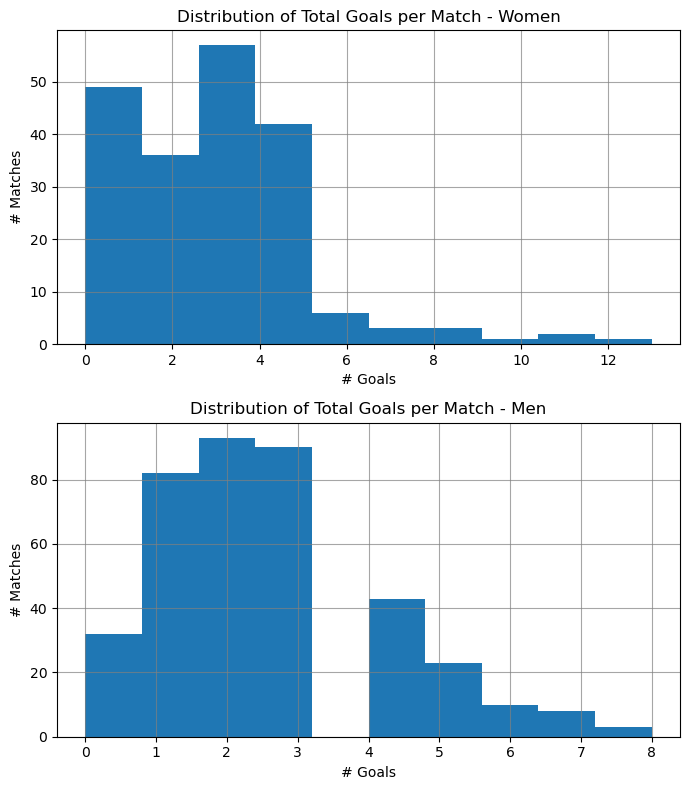

In [74]:
#Evaluate distributions of statistic of interest -- mean # goals in soccer matches

fig, axes = plt.subplots(nrows=2, figsize=(7,8))
#women's data
axes[0].hist(filt_W['total_goals'])
axes[0].set_title('Distribution of Total Goals per Match - Women')
axes[0].set_xlabel('# Goals')
axes[0].set_ylabel('# Matches')
#men's data
axes[1].hist(filt_M['total_goals'])
axes[1].set_title('Distribution of Total Goals per Match - Men')
axes[1].set_xlabel('# Goals')
axes[1].set_ylabel('# Matches')

for i in [0,1]:
    plt.sca(axes[i])
    plt.grid(axis='both',alpha=0.7,color='gray')
    plt.tight_layout();

From these figures, it is clear that the distributions are not symmetrical nor normal. As such, a non-parametric hypothesis test is more appropriate for these sets of data.

In this case, the Wilcoxon-Mann-Whitney method was used to determine the p-value. Particularly, a right-tailed Wilcoxon-Mann-Whitney test.

In [84]:
#Conduct hypothesis test using the Wilcoxon-Mann-Whitney concept (right-tailed / greater)

#use the mannwhitneyu function from the scipy.stats module
hyp_test = mannwhitneyu(x=filt_W["total_goals"], y=filt_M["total_goals"], alternative="greater")
    #display(hyp_test)
#retrieve p-value
p_value = hyp_test[1]
    #display(p_value)

#Assess statistical significance by comparing the p-value to the significance level, α. Recall that alpha was specified as 10% (0.10).
alpha = 0.10
if p_value <= alpha:
    display("{} <= {}".format(p_value, alpha))
    display("The result of the hypothesis test is statistically significant because the p-value is less than or equal to the significance level of 10%. As such, the null hypothesis can be rejected, indicating that the mean number of goals scored in women's international soccer matches is greater than in men's.")
    result_dict = {"p_val":p_value, "result":"reject"}
    
else:
    display("{} !<= {}".format(p_value, alpha))
    display("The result of the hypothesis test is NOT statistically significant because the p-value is NOT less than or equal to the significance level of 10%. As such, the null hypothesis cannot be rejected, indicating that the mean number of goals scored in women's international soccer matches is the same as in men's.")
    result_dict = {"p_val":p_value, "result":"fail to reject"}


'0.005106609825443641 <= 0.1'

"The result of the hypothesis test is statistically significant because the p-value is less than or equal to the significance level of 10%. As such, the null hypothesis can be rejected, indicating that the mean number of goals scored in women's international soccer matches is greater than in men's."

# --------------------------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------------

# DATACAMP SOLUTION

C:\Users\elija\AppData\Local\Temp\ipykernel_18740\4051381771.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  men_subset["group"] = "men"
C:\Users\elija\AppData\Local\Temp\ipykernel_18740\4051381771.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  women_subset["group"] = "women"
C:\Users\elija\AppData\Local\Temp\ipykernel_18740\4051381771.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

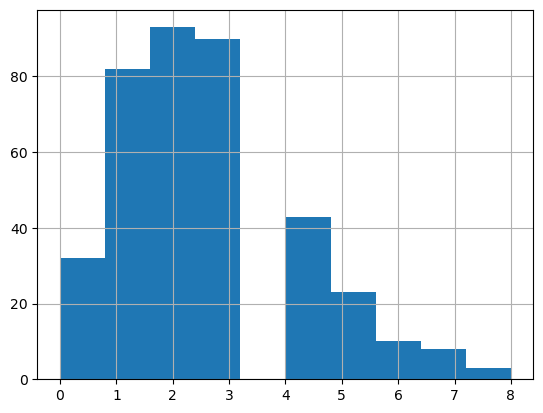

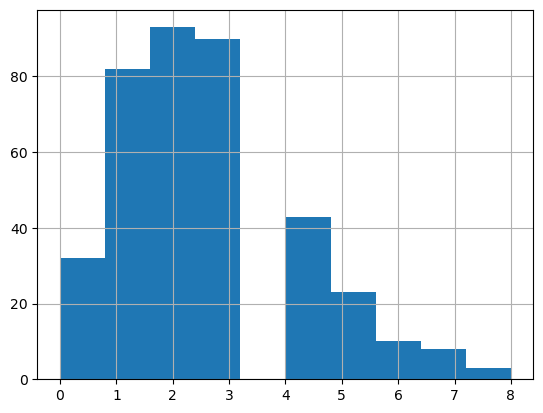

'Scipy P-value: 0.005106609825443641'

<Figure size 640x480 with 0 Axes>

In [47]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
#import pingouin
    #this software can't get pingouin
from scipy.stats import mannwhitneyu

# Load men's and women's datasets
men = pd.read_csv("men_results.csv")
women = pd.read_csv("women_results.csv")

# Filter the data for the time range and tournament
men["date"] = pd.to_datetime(men["date"])
men_subset = men[(men["date"] > "2002-01-01") & (men["tournament"].isin(["FIFA World Cup"]))]
women["date"] = pd.to_datetime(women["date"])
women_subset = women[(women["date"] > "2002-01-01") & (women["tournament"].isin(["FIFA World Cup"]))]

# Create group and goals_scored columns
men_subset["group"] = "men"
women_subset["group"] = "women"
men_subset["goals_scored"] = men_subset["home_score"] + men_subset["away_score"]
women_subset["goals_scored"] = women_subset["home_score"] + women_subset["away_score"]

# Determine normality using histograms
men_subset["goals_scored"].hist()
plt.show()
plt.clf()

# Goals scored is not normally distributed, so use Wilcoxon-Mann-Whitney test of two groups
men_subset["goals_scored"].hist()
plt.show()
plt.clf()

# Combine women's and men's data and calculate goals scored in each match
both = pd.concat([women_subset, men_subset], axis=0, ignore_index=True)

# Transform the data for the pingouin Mann-Whitney U t-test/Wilcoxon-Mann-Whitney test
both_subset = both[["goals_scored", "group"]]
both_subset_wide = both_subset.pivot(columns="group", values="goals_scored")

# Perform right-tailed Wilcoxon-Mann-Whitney test with pingouin
#results_pg = pingouin.mwu(x=both_subset_wide["women"],
#                          y=both_subset_wide["men"],
#                          alternative="greater")

# Alternative SciPy solution: Perform right-tailed Wilcoxon-Mann-Whitney test with scipy
results_scipy = mannwhitneyu(x=women_subset["goals_scored"],
                             y=men_subset["goals_scored"],
                             alternative="greater")

# Extract p-value as a float
#p_val_pg = results_pg["p-val"].values[0]
p_val_scipy = results_scipy[1]

#display("Pingouin P-value: {}".format(p_val_pg))
display("Scipy P-value: {}".format(p_val_scipy))

# Determine hypothesis test result using sig. level
if p_val_scipy <= 0.01:
    result = "reject"
else:
    result = "fail to reject"

#result_dict = {"p_val": p_val, "result": result}